<a href="https://colab.research.google.com/github/josuemarroquinj/corporate-value-portfolio-risk-analysis/blob/main/notebooks/01_market_data_collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Corporate Value, Portfolio Risk and Market Performance")
print("Phase 2 - Market Data Collection")
print("Research period: 2022-01-01 to 2025-12-31")

Corporate Value, Portfolio Risk and Market Performance
Phase 2 - Market Data Collection
Research period: 2022-01-01 to 2025-12-31


# Phase 2 — Market Data Collection and Preparation

## Corporate Value, Portfolio Risk and Market Performance

**Research project:** Doctoral Research in Corporate Finance

**Empirical period:** January 1, 2022 – December 31, 2025

### Objective

This notebook implements the market-data acquisition and preparation stage of the empirical research.

The analysis covers five U.S. publicly traded corporations:

- Amazon (AMZN)
- Nvidia (NVDA)
- Microsoft (MSFT)
- Exxon Mobil (XOM)
- Berkshire Hathaway Class B (BRK-B)

The S&P 500 Index (^GSPC) is used as the market benchmark, while 13-week U.S. Treasury Bill (^IRX) is used as a proxy for the risk-free rate.
Importantly, ^IRX represents a quoted Treasury Bill yield rather than an investable price series. Therefore, percentage changes in ^IRX are not interpreted as security returns. The series is retained separately for the construction of the risk-free rate.

### Main outputs

1. Daily historical prices
2. Adjusted closing prices
3. Trading volume
4. Simple daily returns
5. Logarithmic daily returns
6. Data-quality diagnostics
7. Panel-format dataset
8. Metadata for research reproducibility


In [3]:
# ============================================================
# 1. LIBRARIES
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.6f}"
)

print("Libraries successfully imported.")


Libraries successfully imported.


## 2. Research Design and Parameters

The market-data analysis uses daily observations for the period from January 1, 2022 through December 31, 2025.

The selected companies represent different industries and business models, allowing the subsequent analysis to examine diversification, systematic risk, and portfolio behavior across heterogeneous firms.

The market benchmark is the S&P 500 Index. A short-term U.S. Treasury Bill is initially used as a proxy for the risk-free rate.


In [4]:
# ============================================================
# 2.1 ASSET UNIVERSE
# ============================================================

ASSETS = [
    "AMZN",   # Amazon
    "NVDA",   # Nvidia
    "MSFT",   # Microsoft
    "XOM",    # Exxon Mobil
    "BRK-B"   # Berkshire Hathaway Class B
]

MARKET = "^GSPC"

RISK_FREE = "^IRX"

TICKERS = ASSETS + [
    MARKET,
    RISK_FREE
]

print("Assets:")
for ticker in ASSETS:
    print(f"  - {ticker}")

print(f"\nMarket benchmark: {MARKET}")
print(f"Risk-free proxy: {RISK_FREE}")


Assets:
  - AMZN
  - NVDA
  - MSFT
  - XOM
  - BRK-B

Market benchmark: ^GSPC
Risk-free proxy: ^IRX


In [5]:
# ============================================================
# 2.2 RESEARCH PERIOD
# ============================================================

START_DATE = "2022-01-01"

# yfinance treats the end date as exclusive.
# Therefore, 2026-01-01 allows us to include
# December 31, 2025.

END_DATE = "2026-01-01"

TRADING_DAYS = 252

print(f"Start date: {START_DATE}")
print(f"End date:   {END_DATE}")
print(f"Annualization factor: {TRADING_DAYS} trading days")


Start date: 2022-01-01
End date:   2026-01-01
Annualization factor: 252 trading days


In [6]:
# ============================================================
# 2.3 COMPANY METADATA
# ============================================================

company_info = {
    "AMZN": {
        "Company": "Amazon",
        "Sector": "Consumer Discretionary"
    },

    "NVDA": {
        "Company": "Nvidia",
        "Sector": "Information Technology"
    },

    "MSFT": {
        "Company": "Microsoft",
        "Sector": "Information Technology"
    },

    "XOM": {
        "Company": "Exxon Mobil",
        "Sector": "Energy"
    },

    "BRK-B": {
        "Company": "Berkshire Hathaway",
        "Sector": "Financials / Diversified"
    },

    "^GSPC": {
        "Company": "S&P 500",
        "Sector": "Market Benchmark"
    },

    "^IRX": {
        "Company": "13-Week U.S. Treasury Bill",
        "Sector": "Risk-Free Proxy"
    }
}

company_metadata = pd.DataFrame(
    [
        {
            "Ticker": ticker,
            "Company": info["Company"],
            "Sector": info["Sector"]
        }
        for ticker, info in company_info.items()
    ]
)

company_metadata


,Ticker,Company,Sector
0,AMZN,Amazon,Consumer Discretionary
1,NVDA,Nvidia,Information Technology
2,MSFT,Microsoft,Information Technology
3,XOM,Exxon Mobil,Energy
4,BRK-B,Berkshire Hathaway,Financials / Diversified
5,^GSPC,S&P 500,Market Benchmark
6,^IRX,13-Week U.S. Treasury Bill,Risk-Free Proxy


## 3. Market Data Acquisition

Historical market data are obtained programmatically using the `yfinance` Python library.

The acquisition process is designed to be reproducible: the ticker universe, observation period, frequency, and price-adjustment parameters are explicitly defined in the notebook.


In [7]:
# ============================================================
# 3.1 DOWNLOAD HISTORICAL MARKET DATA
# ============================================================

raw_data = yf.download(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=False,
    actions=True,
    progress=True,
    group_by="column"
)

print("\nDownload completed.")
print(f"Rows:    {raw_data.shape[0]}")
print(f"Columns: {raw_data.shape[1]}")


[*********************100%***********************]  7 of 7 completed



Download completed.
Rows:    1003
Columns: 56


In [11]:
# First five observations
raw_data.head()



Price       Adj Close                                                         \
Ticker           AMZN      BRK-B       MSFT      NVDA       XOM        ^GSPC   
Date                                                                           
2022-01-03 170.404495 300.790009 321.856445 30.026146 54.041134 4,796.560059   
2022-01-04 167.522003 308.529999 316.337585 29.197758 56.073849 4,793.540039   
2022-01-05 164.356995 309.920013 304.194000 27.517071 56.771259 4,700.580078   
2022-01-06 163.253998 313.220001 301.790314 28.089262 58.106556 4,696.049805   
2022-01-07 162.554001 319.779999 301.944183 27.161192 58.582844 4,677.029785   

Price                    Close                                            \
Ticker         ^IRX       AMZN      BRK-B       MSFT      NVDA       XOM   
Date                                                                       
2022-01-03 0.053000 170.404495 300.790009 334.750000 30.121000 63.540001   
2022-01-04 0.080000 167.522003 308.529999 329.010010 29.290001 65.930000   
2022-01-05 0.085000 164.356995 309.920013 316.380005 27.604000 66.750000   
2022-01-06 0.090000 163.253998 313.220001 313.880005 28.177999 68.320000   
2022-01-07 0.088000 162.554001 319.779999 314.040009 27.247000 68.879997   

Price                            Dividends                             \
Ticker            ^GSPC     ^IRX      AMZN    BRK-B     MSFT     NVDA   
Date                                                                    
2022-01-03 4,796.560059 0.053000  0.000000 0.000000 0.000000 0.000000   
2022-01-04 4,793.540039 0.080000  0.000000 0.000000 0.000000 0.000000   
2022-01-05 4,700.580078 0.085000  0.000000 0.000000 0.000000 0.000000   
2022-01-06 4,696.049805 0.090000  0.000000 0.000000 0.000000 0.000000   
2022-01-07 4,677.029785 0.088000  0.000000 0.000000 0.000000 0.000000   

Price                                       High                        \
Ticker          XOM    ^GSPC     ^IRX       AMZN      BRK-B       MSFT   
Date                                                                     
2022-01-03 0.000000 0.000000 0.000000 170.703506 301.299988 338.000000   
2022-01-04 0.000000 0.000000 0.000000 171.399994 309.209991 335.200012   
2022-01-05 0.000000 0.000000 0.000000 167.126495 314.480011 326.070007   
2022-01-06 0.000000 0.000000 0.000000 164.800003 314.109985 318.700012   
2022-01-07 0.000000 0.000000 0.000000 165.243500 320.200012 316.500000   

Price                 ...       Low                                  \
Ticker          NVDA  ...      NVDA       XOM        ^GSPC     ^IRX   
Date                  ...                                             
2022-01-03 30.711000  ... 29.785000 61.209999 4,758.169922 0.050000   
2022-01-04 30.468000  ... 28.349001 64.099998 4,774.270020 0.078000   
2022-01-05 29.416000  ... 27.533001 66.480003 4,699.439941 0.080000   
2022-01-06 28.438000  ... 27.065001 67.070000 4,671.259766 0.083000   
2022-01-07 28.422001  ... 27.056999 67.980003 4,662.740234 0.085000   

Price            Open                                                         \
Ticker           AMZN      BRK-B       MSFT      NVDA       XOM        ^GSPC   
Date                                                                           
2022-01-03 167.550003 300.100006 335.350006 29.815001 61.240002 4,778.140137   
2022-01-04 170.438004 301.649994 334.829987 30.277000 64.129997 4,804.509766   
2022-01-05 166.882996 309.869995 325.859985 28.948999 66.500000 4,787.990234   
2022-01-06 163.450500 312.980011 313.149994 27.639999 68.000000 4,693.390137   
2022-01-07 163.839005 315.559998 314.149994 28.141001 68.519997 4,697.660156   

Price               Stock Splits                                               \
Ticker         ^IRX         AMZN    BRK-B     MSFT     NVDA      XOM    ^GSPC   
Date                                                                            
2022-01-03 0.050000     0.000000 0.000000 0.000000 0.000000 0.000000 0.000000   
2022-01-04 0.085000     0.000000 0.000

In [12]:
# Last five observations
raw_data.tail()

Price       Adj Close                                              \
Ticker           AMZN      BRK-B       MSFT       NVDA        XOM   
Date                                                                
2025-12-24 232.380005 501.339996 484.943420 188.380234 116.875412   
2025-12-26 232.520004 498.299988 484.635406 190.297897 116.767570   
2025-12-29 232.070007 501.049988 484.029236 187.990707 118.159645   
2025-12-30 232.529999 503.709991 484.406860 187.311539 118.610596   
2025-12-31 230.820007 502.649994 480.571167 186.272797 117.973373   

Price                                 Close                                   \
Ticker            ^GSPC     ^IRX       AMZN      BRK-B       MSFT       NVDA   
Date                                                                           
2025-12-24 6,932.049805 3.555000 232.380005 501.339996 488.019989 188.610001   
2025-12-26 6,929.939941 3.543000 232.520004 498.299988 487.709991 190.529999   
2025-12-29 6,905.740234 3.538000 232.070007 501.049988 487.100006 188.220001   
2025-12-30 6,896.240234 3.540000 232.529999 503.709991 487.480011 187.539993   
2025-12-31 6,845.500000 3.547000 230.820007 502.649994 483.619995 186.500000   

Price                                       Dividends                    \
Ticker            XOM        ^GSPC     ^IRX      AMZN    BRK-B     MSFT   
Date                                                                      
2025-12-24 119.220001 6,932.049805 3.555000  0.000000 0.000000 0.000000   
2025-12-26 119.110001 6,929.939941 3.543000  0.000000 0.000000 0.000000   
2025-12-29 120.529999 6,905.740234 3.538000  0.000000 0.000000 0.000000   
2025-12-30 120.989998 6,896.240234 3.540000  0.000000 0.000000 0.000000   
2025-12-31 120.339996 6,845.500000 3.547000  0.000000 0.000000 0.000000   

Price                                                High             \
Ticker         NVDA      XOM    ^GSPC     ^IRX       AMZN      BRK-B   
Date                                                                   
2025-12-24 0.000000 0.000000 0.000000 0.000000 232.949997 501.510010   
2025-12-26 0.000000 0.000000 0.000000 0.000000 232.990005 501.559998   
2025-12-29 0.000000 0.000000 0.000000 0.000000 232.600006 501.500000   
2025-12-30 0.000000 0.000000 0.000000 0.000000 232.770004 505.109985   
2025-12-31 0.000000 0.000000 0.000000 0.000000 232.990005 505.890015   

Price                             ...        Low                          \
Ticker           MSFT       NVDA  ...       NVDA        XOM        ^GSPC   
Date                              ...                                      
2025-12-24 489.160004 188.910004  ... 186.589996 119.120003 6,904.910156   
2025-12-26 488.119995 192.690002  ... 188.000000 118.529999 6,921.600098   
2025-12-29 488.350006 188.759995  ... 185.910004 119.400002 6,888.759766   
2025-12-30 489.679993 188.990005  ... 186.929993 120.629997 6,893.470215   
2025-12-31 488.140015 190.559998  ... 186.490005 119.870003 6,844.549805   

Price                     Open                                              \
Ticker         ^IRX       AMZN      BRK-B       MSFT       NVDA        XOM   
Date                                                                         
2025-12-24 3.525000 232.130005 500.290009 485.679993 187.940002 119.330002   
2025-12-26 3.543000 232.039993 500.450012 486.709991 189.919998 118.889999   
2025-12-29 3.530000 231.940002 499.200012 484.859985 187.710007 120.150002   
2025-12-30 3.540000 231.210007 500.980011 485.929993 188.240005 121.099998   
2025-12-31 3.533000 232.910004 503.920013 487.839996 189.570007 121.180000   

Price                            Stock Splits                             \
Ticker            ^GSPC     ^IRX         AMZN    BRK-B     MSFT     NVDA   
Date                                                                       
2025-12-24 6,904.910156 3.553000     0.000000 0.000000 0.000000 0.000000   
2025-12-26 6,936.020020 3.545000     0.000000 0.000000 0.000000 0.000000   
2025-12-29 6,9

In [13]:
print("Available variables:")

for column in raw_data.columns.levels[0]:
    print(f"  - {column}")

Available variables:
  - Adj Close
  - Close
  - Dividends
  - High
  - Low
  - Open
  - Stock Splits
  - Volume


In [14]:
# ============================================================
# 3.2 EXTRACT ADJUSTED CLOSING PRICES
# ============================================================

adj_close = raw_data["Adj Close"].copy()

print("Adjusted closing prices:")
display(adj_close.head())


Adjusted closing prices:


Ticker,AMZN,BRK-B,MSFT,NVDA,XOM,^GSPC,^IRX
Date,,,,,,,
2022-01-03,170.404495,300.790009,321.856445,30.026146,54.041134,"4,796.560059",0.053000
2022-01-04,167.522003,308.529999,316.337585,29.197758,56.073849,"4,793.540039",0.080000
2022-01-05,164.356995,309.920013,304.194000,27.517071,56.771259,"4,700.580078",0.085000
2022-01-06,163.253998,313.220001,301.790314,28.089262,58.106556,"4,696.049805",0.090000
2022-01-07,162.554001,319.779999,301.944183,27.161192,58.582844,"4,677.029785",0.088000


In [15]:
# ============================================================
# 3.3 DATA AVAILABILITY
# ============================================================

availability = pd.DataFrame({
    "Observations": adj_close.count(),
    "Missing": adj_close.isna().sum(),
    "First Observation": [
        adj_close[ticker].first_valid_index()
        for ticker in adj_close.columns
    ],
    "Last Observation": [
        adj_close[ticker].last_valid_index()
        for ticker in adj_close.columns
    ]
})

availability


,Observations,Missing,First Observation,Last Observation
Ticker,,,,
AMZN,1003,0,2022-01-03,2025-12-31
BRK-B,1003,0,2022-01-03,2025-12-31
MSFT,1003,0,2022-01-03,2025-12-31
NVDA,1003,0,2022-01-03,2025-12-31
XOM,1003,0,2022-01-03,2025-12-31
^GSPC,1003,0,2022-01-03,2025-12-31
^IRX,1003,0,2022-01-03,2025-12-31


In [16]:
# ============================================================
# 3.4 MISSING VALUES
# ============================================================

missing_summary = (
    adj_close
    .isna()
    .sum()
    .to_frame("Missing_Observations")
)

missing_summary


,Missing_Observations
Ticker,
AMZN,0
BRK-B,0
MSFT,0
NVDA,0
XOM,0
^GSPC,0
^IRX,0


In [17]:
if missing_summary["Missing_Observations"].sum() == 0:
    print("No missing observations detected in adjusted prices.")
else:
    print("Missing observations detected. Further inspection required.")


No missing observations detected in adjusted prices.


## 4. Data Quality Validation

Before calculating returns, the downloaded market data are subjected to basic integrity checks.

The validation procedure examines:

1. Date ordering and uniqueness.
2. Missing observations.
3. Duplicate observations.
4. Price validity.
5. Extreme daily movements.
6. Consistency across assets.

These checks are performed before any statistical estimation to reduce the possibility that data-quality problems affect subsequent results.


In [18]:
# ============================================================
# 4.1 DATE INTEGRITY
# ============================================================

print("Number of observations:", len(adj_close))
print("First date:", adj_close.index.min())
print("Last date:", adj_close.index.max())

print("\nDates sorted:", adj_close.index.is_monotonic_increasing)
print("Duplicate dates:", adj_close.index.duplicated().sum())


Number of observations: 1003
First date: 2022-01-03 00:00:00
Last date: 2025-12-31 00:00:00

Dates sorted: True
Duplicate dates: 0


In [19]:
# ============================================================
# 4.2 PRICE VALIDITY
# ============================================================

negative_prices = (adj_close <= 0).sum()

print("Non-positive price observations:")
display(negative_prices.to_frame("Count"))


Non-positive price observations:


,Count
Ticker,
AMZN,0
BRK-B,0
MSFT,0
NVDA,0
XOM,0
^GSPC,0
^IRX,0


In [20]:
# ============================================================
# 4.3 PRELIMINARY EXTREME-MOVEMENT CHECK
# ============================================================

preliminary_returns = adj_close.pct_change()

extreme_threshold = 0.20  # 20%

extreme_observations = (
    preliminary_returns.abs() > extreme_threshold
)

extreme_counts = extreme_observations.sum().sort_values(
    ascending=False
)

print("Observations with absolute daily return > 20%:")
display(
    extreme_counts.to_frame("Count")
)


Observations with absolute daily return > 20%:


,Count
Ticker,
^IRX,6
NVDA,1
AMZN,0
MSFT,0
BRK-B,0
XOM,0
^GSPC,0


In [21]:
# ============================================================
# 4.4 EXTREME-RETURN OBSERVATIONS
# ============================================================

extreme_events = preliminary_returns.where(
    preliminary_returns.abs() > extreme_threshold
).stack()

extreme_events = (
    extreme_events
    .reset_index()
)

extreme_events.columns = [
    "Date",
    "Ticker",
    "Return"
]

extreme_events = extreme_events.sort_values(
    "Return"
)

display(extreme_events)


,Date,Ticker,Return
5,2022-04-05,^IRX,0.241636
6,2023-05-25,NVDA,0.243697
2,2022-01-19,^IRX,0.269231
1,2022-01-11,^IRX,0.311111
3,2022-02-08,^IRX,0.354680
4,2022-02-10,^IRX,0.370370
0,2022-01-04,^IRX,0.509434


## 5. Return Construction

Daily returns are calculated from adjusted closing prices.

Adjusted prices are used because the analysis focuses on investor returns rather than unadjusted price changes. This approach incorporates relevant corporate actions reflected in the adjusted price series.

Two return measures are constructed:

- Simple daily returns.
- Logarithmic daily returns.

Simple returns are used primarily for portfolio aggregation and VaR calculations, while logarithmic returns are retained for statistical and econometric analysis.


In [22]:
# ============================================================
# 5.1 SIMPLE DAILY RETURNS
# ============================================================

returns = adj_close.pct_change()

returns = returns.dropna(how="all")

print("Simple returns dataset:")
print("Rows:", returns.shape[0])
print("Columns:", returns.shape[1])

display(returns.head())


Simple returns dataset:
Rows: 1002
Columns: 7


Ticker,AMZN,BRK-B,MSFT,NVDA,XOM,^GSPC,^IRX
Date,,,,,,,
2022-01-04,-0.016916,0.025732,-0.017147,-0.027589,0.037614,-0.000630,0.509434
2022-01-05,-0.018893,0.004505,-0.038388,-0.057562,0.012437,-0.019393,0.062500
2022-01-06,-0.006711,0.010648,-0.007902,0.020794,0.023521,-0.000964,0.058824
2022-01-07,-0.004288,0.020944,0.000510,-0.033040,0.008197,-0.004050,-0.022222
2022-01-10,-0.006570,-0.002658,0.000732,0.005615,-0.005953,-0.001441,0.022727


In [23]:
# ============================================================
# 5.2 LOGARITHMIC DAILY RETURNS
# ============================================================

log_returns = np.log(
    adj_close / adj_close.shift(1)
)

log_returns = log_returns.dropna(how="all")

print("Logarithmic returns dataset:")
print("Rows:", log_returns.shape[0])
print("Columns:", log_returns.shape[1])

display(log_returns.head())


Logarithmic returns dataset:
Rows: 1002
Columns: 7


Ticker,AMZN,BRK-B,MSFT,NVDA,XOM,^GSPC,^IRX
Date,,,,,,,
2022-01-04,-0.017060,0.025407,-0.017296,-0.027977,0.036924,-0.000630,0.411735
2022-01-05,-0.019074,0.004495,-0.039144,-0.059285,0.012361,-0.019583,0.060625
2022-01-06,-0.006734,0.010592,-0.007933,0.020581,0.023248,-0.000964,0.057158
2022-01-07,-0.004297,0.020727,0.000510,-0.033598,0.008163,-0.004058,-0.022473
2022-01-10,-0.006592,-0.002662,0.000732,0.005600,-0.005970,-0.001442,0.022473


In [24]:
# ============================================================
# 5.3 RETURN COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Simple_Return": returns["AMZN"],
    "Log_Return": log_returns["AMZN"]
})

display(comparison.head(10))


,Simple_Return,Log_Return
Date,,
2022-01-04,-0.016916,-0.017060
2022-01-05,-0.018893,-0.019074
2022-01-06,-0.006711,-0.006734
2022-01-07,-0.004288,-0.004297
2022-01-10,-0.006570,-0.006592
2022-01-11,0.024002,0.023719
2022-01-12,-0.000937,-0.000938
2022-01-13,-0.024170,-0.024467
2022-01-14,0.005731,0.005715


In [25]:
# ============================================================
# 5.4 DESCRIPTIVE STATISTICS
# ============================================================

return_statistics = returns[ASSETS].describe().T

return_statistics


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AMZN,"1,002.000000",0.000579,0.023546,-0.140494,-0.012153,0.000418,0.013622,0.135359
NVDA,"1,002.000000",0.002393,0.033950,-0.169682,-0.017373,0.002990,0.021395,0.243697
MSFT,"1,002.000000",0.000542,0.016868,-0.077156,-0.007981,0.000771,0.009777,0.101337
XOM,"1,002.000000",0.000917,0.016577,-0.078853,-0.008653,0.001006,0.011193,0.064113
BRK-B,"1,002.000000",0.000575,0.011157,-0.069073,-0.005597,0.000677,0.006984,0.058400


In [26]:
# ============================================================
# 5.5 ANNUALIZED RETURN AND VOLATILITY
# ============================================================

annualized_statistics = pd.DataFrame(index=ASSETS)

annualized_statistics["Mean_Daily_Return"] = returns[ASSETS].mean()

annualized_statistics["Annualized_Return"] = (
    returns[ASSETS].mean() * TRADING_DAYS
)

annualized_statistics["Daily_Volatility"] = (
    returns[ASSETS].std()
)

annualized_statistics["Annualized_Volatility"] = (
    returns[ASSETS].std() * np.sqrt(TRADING_DAYS)
)

annualized_statistics["Minimum_Daily_Return"] = (
    returns[ASSETS].min()
)

annualized_statistics["Maximum_Daily_Return"] = (
    returns[ASSETS].max()
)

annualized_statistics


,Mean_Daily_Return,Annualized_Return,Daily_Volatility,Annualized_Volatility,Minimum_Daily_Return,Maximum_Daily_Return
AMZN,0.000579,0.146033,0.023546,0.373782,-0.140494,0.135359
NVDA,0.002393,0.602973,0.033950,0.538946,-0.169682,0.243697
MSFT,0.000542,0.136562,0.016868,0.267767,-0.077156,0.101337
XOM,0.000917,0.231096,0.016577,0.263154,-0.078853,0.064113
BRK-B,0.000575,0.144840,0.011157,0.177114,-0.069073,0.058400


In [27]:
# ============================================================
# 5.6 CORRELATION MATRIX
# ============================================================

correlation_matrix = returns[ASSETS].corr()

correlation_matrix


Ticker,AMZN,NVDA,MSFT,XOM,BRK-B
Ticker,,,,,
AMZN,1.000000,0.559691,0.667574,0.136856,0.381049
NVDA,0.559691,1.000000,0.637773,0.084496,0.278777
MSFT,0.667574,0.637773,1.000000,0.095600,0.397605
XOM,0.136856,0.084496,0.095600,1.000000,0.396629
BRK-B,0.381049,0.278777,0.397605,0.396629,1.000000


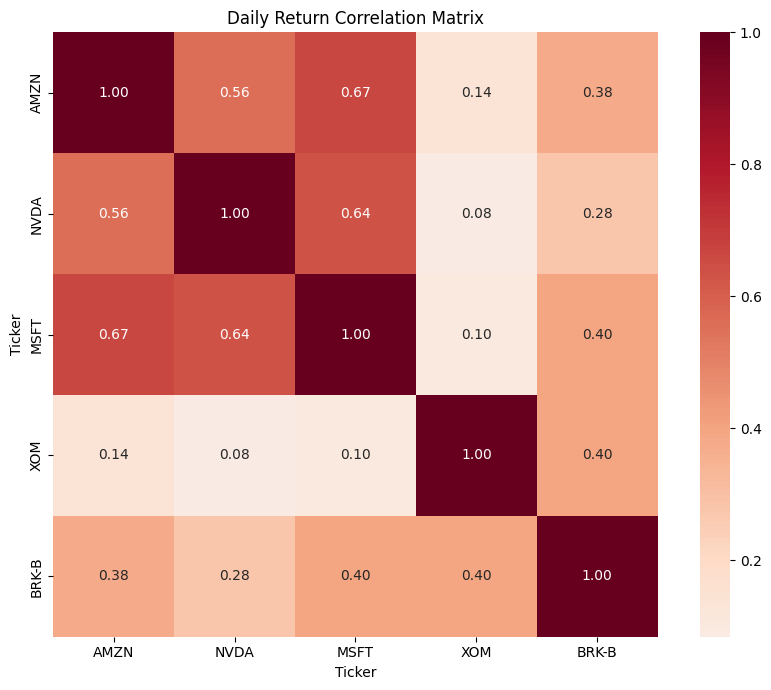

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True
)

plt.title("Daily Return Correlation Matrix")
plt.tight_layout()

plt.show()


In [29]:
# ============================================================
# 5.7 COVARIANCE MATRIX
# ============================================================

covariance_matrix = returns[ASSETS].cov()

covariance_matrix


Ticker,AMZN,NVDA,MSFT,XOM,BRK-B
Ticker,,,,,
AMZN,0.000554,0.000447,0.000265,0.000053,0.000100
NVDA,0.000447,0.001153,0.000365,0.000048,0.000106
MSFT,0.000265,0.000365,0.000285,0.000027,0.000075
XOM,0.000053,0.000048,0.000027,0.000275,0.000073
BRK-B,0.000100,0.000106,0.000075,0.000073,0.000124


In [30]:
annualized_covariance = (
    covariance_matrix * TRADING_DAYS
)

annualized_covariance


Ticker,AMZN,NVDA,MSFT,XOM,BRK-B
Ticker,,,,,
AMZN,0.139713,0.112749,0.066815,0.013461,0.025226
NVDA,0.112749,0.290463,0.092038,0.011984,0.026611
MSFT,0.066815,0.092038,0.071699,0.006736,0.018856
XOM,0.013461,0.011984,0.006736,0.069250,0.018486
BRK-B,0.025226,0.026611,0.018856,0.018486,0.031369


In [31]:
# ============================================================
# 5.8 CREATE OUTPUT DIRECTORIES
# ============================================================

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)
os.makedirs("../results/tables", exist_ok=True)

print("Output directories created.")


Output directories created.


In [32]:
# ============================================================
# 5. RETURN-ELIGIBLE ASSETS
# ============================================================

RETURN_ASSETS = ASSETS + [MARKET]

print("Assets included in return calculations:")
print(RETURN_ASSETS)

print("\nRisk-free series treated separately:")
print(RISK_FREE)


Assets included in return calculations:
['AMZN', 'NVDA', 'MSFT', 'XOM', 'BRK-B', '^GSPC']

Risk-free series treated separately:
^IRX


In [33]:
# ============================================================
# 5.1 SIMPLE DAILY RETURNS — ASSETS AND MARKET
# ============================================================

returns = adj_close[RETURN_ASSETS].pct_change()

returns = returns.dropna(how="all")

display(returns.head())


Ticker,AMZN,NVDA,MSFT,XOM,BRK-B,^GSPC
Date,,,,,,
2022-01-04,-0.016916,-0.027589,-0.017147,0.037614,0.025732,-0.000630
2022-01-05,-0.018893,-0.057562,-0.038388,0.012437,0.004505,-0.019393
2022-01-06,-0.006711,0.020794,-0.007902,0.023521,0.010648,-0.000964
2022-01-07,-0.004288,-0.033040,0.000510,0.008197,0.020944,-0.004050
2022-01-10,-0.006570,0.005615,0.000732,-0.005953,-0.002658,-0.001441


In [34]:
# ============================================================
# 5.2 LOGARITHMIC RETURNS — ASSETS AND MARKET
# ============================================================

log_returns = np.log(
    adj_close[RETURN_ASSETS] /
    adj_close[RETURN_ASSETS].shift(1)
)

log_returns = log_returns.dropna(how="all")

display(log_returns.head())


Ticker,AMZN,NVDA,MSFT,XOM,BRK-B,^GSPC
Date,,,,,,
2022-01-04,-0.017060,-0.027977,-0.017296,0.036924,0.025407,-0.000630
2022-01-05,-0.019074,-0.059285,-0.039144,0.012361,0.004495,-0.019583
2022-01-06,-0.006734,0.020581,-0.007933,0.023248,0.010592,-0.000964
2022-01-07,-0.004297,-0.033598,0.000510,0.008163,0.020727,-0.004058
2022-01-10,-0.006592,0.005600,0.000732,-0.005970,-0.002662,-0.001442


In [35]:
# ============================================================
# 5.3 EXTREME RETURN CHECK — EXCLUDING RISK-FREE YIELD
# ============================================================

extreme_threshold = 0.20

extreme_observations = (
    returns.abs() > extreme_threshold
)

extreme_counts = (
    extreme_observations
    .sum()
    .sort_values(ascending=False)
)

print("Observations with absolute daily return > 20%:")
display(
    extreme_counts.to_frame("Count")
)


Observations with absolute daily return > 20%:


,Count
Ticker,
NVDA,1
AMZN,0
MSFT,0
XOM,0
BRK-B,0
^GSPC,0


In [36]:
extreme_events = returns.where(
    returns.abs() > extreme_threshold
).stack()

extreme_events = (
    extreme_events
    .reset_index()
)

extreme_events.columns = [
    "Date",
    "Ticker",
    "Return"
]

extreme_events = extreme_events.sort_values(
    "Return"
)

display(extreme_events)


,Date,Ticker,Return
0,2023-05-25,NVDA,0.243697


## 6. Descriptive Analysis of Market Returns

This section provides descriptive statistics for the daily returns of the five selected corporations and the S&P 500 market benchmark.

The analysis considers the central tendency, dispersion, minimum and maximum observations, and distributional characteristics of daily returns.

The descriptive analysis provides the empirical basis for the subsequent estimation of systematic risk, portfolio risk, and Value-at-Risk.


In [37]:
# ============================================================
# 6.1 DESCRIPTIVE STATISTICS
# ============================================================

return_statistics = returns[ASSETS].describe().T

return_statistics


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AMZN,"1,002.000000",0.000579,0.023546,-0.140494,-0.012153,0.000418,0.013622,0.135359
NVDA,"1,002.000000",0.002393,0.033950,-0.169682,-0.017373,0.002990,0.021395,0.243697
MSFT,"1,002.000000",0.000542,0.016868,-0.077156,-0.007981,0.000771,0.009777,0.101337
XOM,"1,002.000000",0.000917,0.016577,-0.078853,-0.008653,0.001006,0.011193,0.064113
BRK-B,"1,002.000000",0.000575,0.011157,-0.069073,-0.005597,0.000677,0.006984,0.058400


In [38]:
# ============================================================
# 6.2 ANNUALIZED PERFORMANCE AND RISK
# ============================================================

annualized_statistics = pd.DataFrame(index=ASSETS)

annualized_statistics["Mean Daily Return"] = (
    returns[ASSETS].mean()
)

annualized_statistics["Annualized Return"] = (
    returns[ASSETS].mean() * TRADING_DAYS
)

annualized_statistics["Daily Volatility"] = (
    returns[ASSETS].std()
)

annualized_statistics["Annualized Volatility"] = (
    returns[ASSETS].std() * np.sqrt(TRADING_DAYS)
)

annualized_statistics["Minimum Daily Return"] = (
    returns[ASSETS].min()
)

annualized_statistics["Maximum Daily Return"] = (
    returns[ASSETS].max()
)

annualized_statistics


,Mean Daily Return,Annualized Return,Daily Volatility,Annualized Volatility,Minimum Daily Return,Maximum Daily Return
AMZN,0.000579,0.146033,0.023546,0.373782,-0.140494,0.135359
NVDA,0.002393,0.602973,0.033950,0.538946,-0.169682,0.243697
MSFT,0.000542,0.136562,0.016868,0.267767,-0.077156,0.101337
XOM,0.000917,0.231096,0.016577,0.263154,-0.078853,0.064113
BRK-B,0.000575,0.144840,0.011157,0.177114,-0.069073,0.058400


In [39]:
# ============================================================
# 6.3 PRESENTATION FORMAT
# ============================================================

annualized_statistics_pct = (
    annualized_statistics * 100
)

annualized_statistics_pct.round(2)


,Mean Daily Return,Annualized Return,Daily Volatility,Annualized Volatility,Minimum Daily Return,Maximum Daily Return
AMZN,0.060000,14.600000,2.350000,37.380000,-14.050000,13.540000
NVDA,0.240000,60.300000,3.400000,53.890000,-16.970000,24.370000
MSFT,0.050000,13.660000,1.690000,26.780000,-7.720000,10.130000
XOM,0.090000,23.110000,1.660000,26.320000,-7.890000,6.410000
BRK-B,0.060000,14.480000,1.120000,17.710000,-6.910000,5.840000


## 7. Dependence Structure and Diversification

Modern Portfolio Theory emphasizes that portfolio risk depends not only on the individual volatility of assets but also on the covariance structure among their returns.

Therefore, the empirical analysis examines the correlation and covariance matrices of the selected securities.


In [40]:
# ============================================================
# 7.1 CORRELATION MATRIX
# ============================================================

correlation_matrix = returns[ASSETS].corr()

correlation_matrix.round(3)


Ticker,AMZN,NVDA,MSFT,XOM,BRK-B
Ticker,,,,,
AMZN,1.000000,0.560000,0.668000,0.137000,0.381000
NVDA,0.560000,1.000000,0.638000,0.084000,0.279000
MSFT,0.668000,0.638000,1.000000,0.096000,0.398000
XOM,0.137000,0.084000,0.096000,1.000000,0.397000
BRK-B,0.381000,0.279000,0.398000,0.397000,1.000000


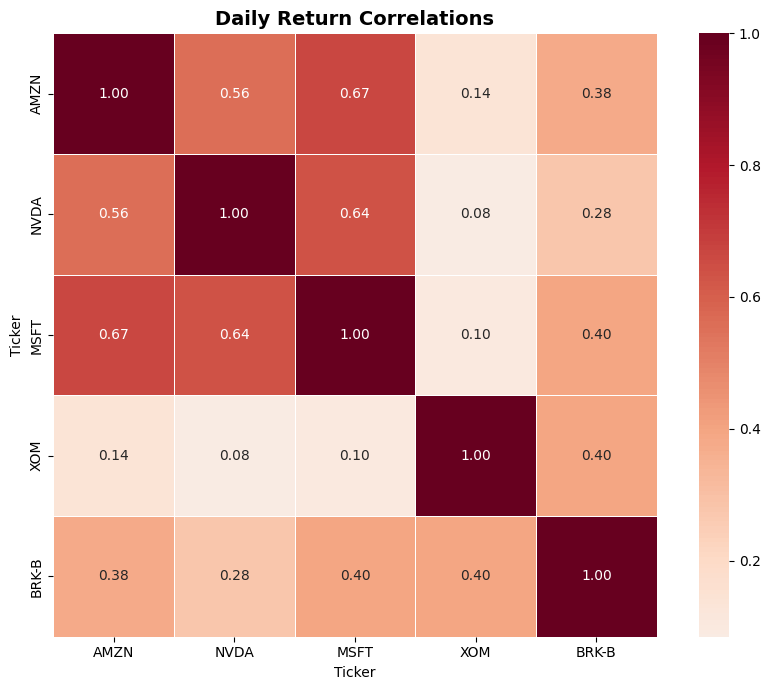

In [41]:
# ============================================================
# 7.2 CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title(
    "Daily Return Correlations",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


In [42]:
# ============================================================
# 7.3 COVARIANCE MATRIX
# ============================================================

covariance_matrix = returns[ASSETS].cov()

covariance_matrix.round(6)


Ticker,AMZN,NVDA,MSFT,XOM,BRK-B
Ticker,,,,,
AMZN,0.000554,0.000447,0.000265,0.000053,0.000100
NVDA,0.000447,0.001153,0.000365,0.000048,0.000106
MSFT,0.000265,0.000365,0.000285,0.000027,0.000075
XOM,0.000053,0.000048,0.000027,0.000275,0.000073
BRK-B,0.000100,0.000106,0.000075,0.000073,0.000124


In [43]:
# Annualized covariance matrix

annualized_covariance = (
    covariance_matrix * TRADING_DAYS
)

annualized_covariance.round(6)


Ticker,AMZN,NVDA,MSFT,XOM,BRK-B
Ticker,,,,,
AMZN,0.139713,0.112749,0.066815,0.013461,0.025226
NVDA,0.112749,0.290463,0.092038,0.011984,0.026611
MSFT,0.066815,0.092038,0.071699,0.006736,0.018856
XOM,0.013461,0.011984,0.006736,0.069250,0.018486
BRK-B,0.025226,0.026611,0.018856,0.018486,0.031369


## 8. Cumulative Performance and Compound Annual Growth Rate

In addition to annualized arithmetic returns, cumulative performance and the compound annual growth rate (CAGR) are calculated.

Cumulative return measures the total change in the adjusted price over the sample period:

\[
R_{cum} = \frac{P_T}{P_0}-1
\]

The CAGR is calculated as:

\[
CAGR =
\left(
\frac{P_T}{P_0}
\right)^{1/n}-1
\]

where \(n\) represents the number of years in the investment period.


In [44]:
# ============================================================
# 8.1 CUMULATIVE RETURN
# ============================================================

cumulative_returns = (
    adj_close[ASSETS].iloc[-1] /
    adj_close[ASSETS].iloc[0]
) - 1

cumulative_returns


,0
Ticker,
AMZN,0.354542
NVDA,5.203687
MSFT,0.493123
XOM,1.183029
BRK-B,0.671099


In [45]:
# ============================================================
# 8.2 CAGR
# ============================================================

start_date = adj_close[ASSETS].index.min()
end_date = adj_close[ASSETS].index.max()

years = (
    end_date - start_date
).days / 365.25

cagr = (
    (adj_close[ASSETS].iloc[-1] /
     adj_close[ASSETS].iloc[0])
    ** (1 / years)
) - 1

cagr = cagr.sort_values(
    ascending=False
)

cagr


,0
Ticker,
NVDA,0.579684
XOM,0.216016
BRK-B,0.137274
MSFT,0.105639
AMZN,0.078986


In [46]:
# ============================================================
# 8.3 PERFORMANCE SUMMARY
# ============================================================

performance_summary = pd.DataFrame(index=ASSETS)

performance_summary["Mean Annualized Return"] = (
    returns[ASSETS].mean() * TRADING_DAYS
)

performance_summary["Cumulative Return"] = (
    cumulative_returns
)

performance_summary["CAGR"] = (
    cagr
)

performance_summary["Annualized Volatility"] = (
    returns[ASSETS].std() * np.sqrt(TRADING_DAYS)
)

performance_summary["Minimum Daily Return"] = (
    returns[ASSETS].min()
)

performance_summary["Maximum Daily Return"] = (
    returns[ASSETS].max()
)

performance_summary = (
    performance_summary
    .sort_values(
        "CAGR",
        ascending=False
    )
)

performance_summary.round(4)


,Mean Annualized Return,Cumulative Return,CAGR,Annualized Volatility,Minimum Daily Return,Maximum Daily Return
NVDA,0.603000,5.203700,0.579700,0.538900,-0.169700,0.243700
XOM,0.231100,1.183000,0.216000,0.263200,-0.078900,0.064100
BRK-B,0.144800,0.671100,0.137300,0.177100,-0.069100,0.058400
MSFT,0.136600,0.493100,0.105600,0.267800,-0.077200,0.101300
AMZN,0.146000,0.354500,0.079000,0.373800,-0.140500,0.135400


In [47]:
performance_summary_pct = (
    performance_summary * 100
)

performance_summary_pct.round(2)


,Mean Annualized Return,Cumulative Return,CAGR,Annualized Volatility,Minimum Daily Return,Maximum Daily Return
NVDA,60.300000,520.370000,57.970000,53.890000,-16.970000,24.370000
XOM,23.110000,118.300000,21.600000,26.320000,-7.890000,6.410000
BRK-B,14.480000,67.110000,13.730000,17.710000,-6.910000,5.840000
MSFT,13.660000,49.310000,10.560000,26.780000,-7.720000,10.130000
AMZN,14.600000,35.450000,7.900000,37.380000,-14.050000,13.540000


## 9. Drawdown Analysis

Drawdown measures the decline in an asset's value from a previous historical peak.

For each asset:

\[
DD_t =
\frac{P_t}{\max(P_1,\ldots,P_t)}-1
\]

Maximum drawdown is the minimum value of the drawdown series and provides an additional measure of downside risk beyond standard deviation.
The reported maximum drawdown represents the largest peak-to-trough decline observed within the 2022–2025 sample period and should not be interpreted as the historical maximum drawdown over the entire trading history of each security.


In [49]:
# ============================================================
# 9.1 DRAWDOWN
# ============================================================

wealth_index = (
    adj_close[ASSETS] /
    adj_close[ASSETS].iloc[0]
)

running_max = wealth_index.cummax()

drawdown = (
    wealth_index / running_max
) - 1

maximum_drawdown = drawdown.min()

maximum_drawdown = (
    maximum_drawdown
    .sort_values()
)

maximum_drawdown


,0
Ticker,
NVDA,-0.627017
AMZN,-0.519848
MSFT,-0.355788
BRK-B,-0.265790
XOM,-0.205086


In [50]:
# Maximum drawdown in percentage terms

(maximum_drawdown * 100).round(2)


,0
Ticker,
NVDA,-62.700000
AMZN,-51.980000
MSFT,-35.580000
BRK-B,-26.580000
XOM,-20.510000


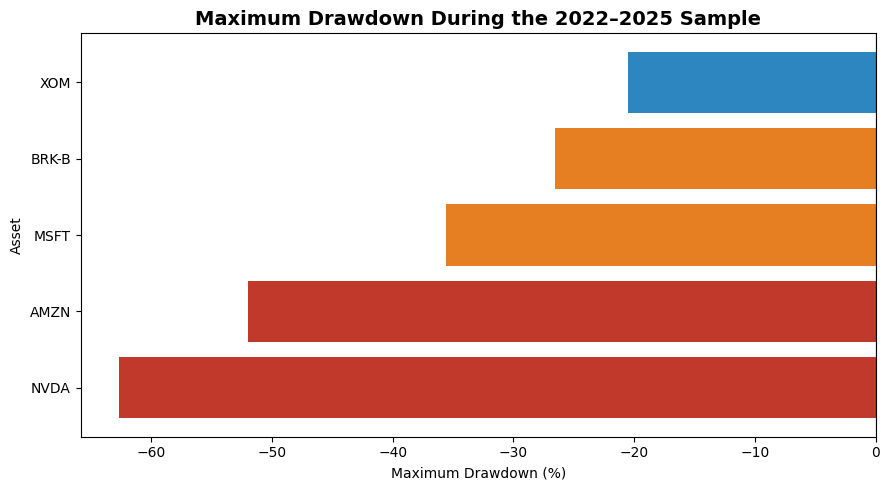

In [51]:
# ============================================================
# 9.2 MAXIMUM DRAWDOWN COMPARISON
# ============================================================

drawdown_plot = (
    maximum_drawdown
    .sort_values()
    .mul(100)
)

plt.figure(figsize=(9, 5))

colors = [
    "#C0392B" if x < -40 else
    "#E67E22" if x < -25 else
    "#2E86C1"
    for x in drawdown_plot.values
]

plt.barh(
    drawdown_plot.index,
    drawdown_plot.values,
    color=colors
)

plt.axvline(
    0,
    color="black",
    linewidth=0.8
)

plt.xlabel("Maximum Drawdown (%)")
plt.ylabel("Asset")

plt.title(
    "Maximum Drawdown During the 2022–2025 Sample",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


In [52]:
# ============================================================
# 10.1 INSPECT RISK-FREE RATE SERIES
# ============================================================

irx = adj_close[RISK_FREE].copy()

print("Risk-free proxy observations:")
display(irx.head())

print("\nDescriptive statistics:")
display(irx.describe())


Risk-free proxy observations:


,^IRX
Date,
2022-01-03,0.053000
2022-01-04,0.080000
2022-01-05,0.085000
2022-01-06,0.090000
2022-01-07,0.088000



Descriptive statistics:


,^IRX
count,"1,003.000000"
mean,4.011432
std,1.453052
min,0.053000
25%,3.832500
50%,4.250000
75%,5.200000
max,5.348000


In [53]:
# ============================================================
# 10.2 RISK-FREE RATE RANGE
# ============================================================

print("Minimum ^IRX value:", irx.min())
print("Maximum ^IRX value:", irx.max())

print("\nLast 10 observations:")
display(irx.tail(10))


Minimum ^IRX value: 0.05299999937415123
Maximum ^IRX value: 5.3480000495910645

Last 10 observations:


,^IRX
Date,
2025-12-17,3.543000
2025-12-18,3.522000
2025-12-19,3.522000
2025-12-22,3.528000
2025-12-23,3.547000
2025-12-24,3.555000
2025-12-26,3.543000
2025-12-29,3.538000
2025-12-30,3.540000


In [54]:
# ============================================================
# 10.3 DAILY RISK-FREE RATE
# ============================================================

risk_free_daily = (
    (1 + irx / 100) ** (1 / TRADING_DAYS)
) - 1

risk_free_daily.name = "Risk_Free_Daily"

print("Daily risk-free rate:")
display(risk_free_daily.head())

print("\nDescriptive statistics:")
display(risk_free_daily.describe())


Daily risk-free rate:


,Risk_Free_Daily
Date,
2022-01-03,0.000002
2022-01-04,0.000003
2022-01-05,0.000003
2022-01-06,0.000004
2022-01-07,0.000003



Descriptive statistics:


,Risk_Free_Daily
count,"1,003.000000"
mean,0.000156
std,0.000056
min,0.000002
25%,0.000149
50%,0.000165
75%,0.000201
max,0.000207


In [55]:
# ============================================================
# 10.4 RISK-FREE RATE CONVERSION CHECK
# ============================================================

rf_check = pd.DataFrame({
    "IRX_Annual_Yield_%": irx,
    "Risk_Free_Daily": risk_free_daily,
    "Risk_Free_Daily_%": risk_free_daily * 100
})

display(rf_check.head(10))


,IRX_Annual_Yield_%,Risk_Free_Daily,Risk_Free_Daily_%
Date,,,
2022-01-03,0.053000,0.000002,0.000210
2022-01-04,0.080000,0.000003,0.000317
2022-01-05,0.085000,0.000003,0.000337
2022-01-06,0.090000,0.000004,0.000357
2022-01-07,0.088000,0.000003,0.000349
2022-01-10,0.090000,0.000004,0.000357
2022-01-11,0.118000,0.000005,0.000468
2022-01-12,0.115000,0.000005,0.000456
2022-01-13,0.110000,0.000004,0.000436


In [56]:
# ============================================================
# 10.5 ALIGN RISK-FREE RATE WITH ASSET RETURNS
# ============================================================

analysis_data = returns[ASSETS + [MARKET]].copy()

analysis_data["Risk_Free"] = (
    risk_free_daily
)

analysis_data = analysis_data.dropna()

print("Final observations available for CAPM and Sharpe:")
print(analysis_data.shape)

display(analysis_data.head())


Final observations available for CAPM and Sharpe:
(1002, 7)


Ticker,AMZN,NVDA,MSFT,XOM,BRK-B,^GSPC,Risk_Free
Date,,,,,,,
2022-01-04,-0.016916,-0.027589,-0.017147,0.037614,0.025732,-0.000630,0.000003
2022-01-05,-0.018893,-0.057562,-0.038388,0.012437,0.004505,-0.019393,0.000003
2022-01-06,-0.006711,0.020794,-0.007902,0.023521,0.010648,-0.000964,0.000004
2022-01-07,-0.004288,-0.033040,0.000510,0.008197,0.020944,-0.004050,0.000003
2022-01-10,-0.006570,0.005615,0.000732,-0.005953,-0.002658,-0.001441,0.000004


In [57]:
# ============================================================
# 10.6 EXCESS RETURNS
# ============================================================

excess_returns = pd.DataFrame(
    index=analysis_data.index
)

for asset in ASSETS:
    excess_returns[asset] = (
        analysis_data[asset]
        - analysis_data["Risk_Free"]
    )

excess_returns["Market"] = (
    analysis_data[MARKET]
    - analysis_data["Risk_Free"]
)

display(excess_returns.head())


,AMZN,NVDA,MSFT,XOM,BRK-B,Market
Date,,,,,,
2022-01-04,-0.016919,-0.027592,-0.017150,0.037611,0.025729,-0.000633
2022-01-05,-0.018896,-0.057566,-0.038391,0.012434,0.004502,-0.019396
2022-01-06,-0.006715,0.020790,-0.007905,0.023517,0.010644,-0.000967
2022-01-07,-0.004291,-0.033044,0.000506,0.008193,0.020940,-0.004054
2022-01-10,-0.006574,0.005612,0.000729,-0.005956,-0.002662,-0.001445


In [58]:
# ============================================================
# 11.1 SHARPE RATIO
# ============================================================

sharpe_ratio = (
    excess_returns[ASSETS].mean() * TRADING_DAYS
) / (
    returns[ASSETS].std() * np.sqrt(TRADING_DAYS)
)

sharpe_ratio = (
    sharpe_ratio
    .sort_values(ascending=False)
)

print("Annualized Sharpe Ratios:")
display(sharpe_ratio.round(3))


Annualized Sharpe Ratios:


,0
NVDA,1.046000
XOM,0.729000
BRK-B,0.596000
MSFT,0.363000
AMZN,0.286000


## 12. Systematic Risk: Beta and CAPM

The Capital Asset Pricing Model (CAPM) provides the theoretical framework for estimating the systematic risk of each security relative to the market portfolio.

The model is specified as:

\[
R_{i,t}-R_{f,t}
=
\alpha_i+
\beta_i(R_{m,t}-R_{f,t})
+\epsilon_{i,t}
\]

where:

- \(R_{i,t}\) is the return of asset \(i\);
- \(R_{f,t}\) is the risk-free rate;
- \(R_{m,t}\) is the market return;
- \(\alpha_i\) represents abnormal performance;
- \(\beta_i\) measures systematic risk;
- \(\epsilon_{i,t}\) is the idiosyncratic component.


In [59]:
# ============================================================
# 12.1 BETA — COVARIANCE METHOD
# ============================================================

market_excess = excess_returns["Market"]

beta_covariance = {}

for asset in ASSETS:

    beta_covariance[asset] = (
        excess_returns[asset].cov(market_excess)
        /
        market_excess.var()
    )

beta_covariance = pd.Series(
    beta_covariance,
    name="Beta"
)

beta_covariance = (
    beta_covariance
    .sort_values(ascending=False)
)

display(beta_covariance.round(4))


,Beta
NVDA,2.182200
AMZN,1.544000
MSFT,1.155300
BRK-B,0.644400
XOM,0.481500


In [60]:
risk_free_daily.describe()


,Risk_Free_Daily
count,"1,003.000000"
mean,0.000156
std,0.000056
min,0.000002
25%,0.000149
50%,0.000165
75%,0.000201
max,0.000207


In [61]:
sharpe_ratio.round(3)


,0
NVDA,1.046000
XOM,0.729000
BRK-B,0.596000
MSFT,0.363000
AMZN,0.286000


In [62]:
beta_covariance.round(4)


,Beta
NVDA,2.182200
AMZN,1.544000
MSFT,1.155300
BRK-B,0.644400
XOM,0.481500


## 12.2 Ordinary Least Squares Estimation of CAPM

To complement the covariance-based beta estimates, the CAPM is estimated using Ordinary Least Squares (OLS).

For each security, the following regression is estimated:

\[
R_{i,t}-R_{f,t}
=
\alpha_i+
\beta_i(R_{m,t}-R_{f,t})
+\epsilon_{i,t}
\]

The OLS framework allows the analysis to go beyond the point estimate of beta by evaluating statistical significance, model fit, and confidence intervals.

The estimated coefficients are interpreted as follows:

- \(\alpha_i\): average abnormal excess return not explained by market exposure;
- \(\beta_i\): systematic risk relative to the market;
- \(R^2\): proportion of variation in excess returns explained by market excess returns.


In [63]:
# ============================================================
# 12.3 OLS / CAPM
# ============================================================

import statsmodels.api as sm

print("statsmodels successfully imported.")


statsmodels successfully imported.


In [64]:
# ============================================================
# 12.4 CAPM — NVDA
# ============================================================

y = excess_returns["NVDA"]

X = excess_returns["Market"]

X = sm.add_constant(X)

capm_nvda = sm.OLS(
    y,
    X
).fit()

print(capm_nvda.summary())


                            OLS Regression Results                            
Dep. Variable:                   NVDA   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.519
Method:                 Least Squares   F-statistic:                     1083.
Date:                Sat, 29 Aug 2026   Prob (F-statistic):          1.55e-161
Time:                        19:31:49   Log-Likelihood:                 2336.1
No. Observations:                1002   AIC:                            -4668.
Df Residuals:                    1000   BIC:                            -4658.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.001      2.239      0.0

In [66]:
# ============================================================
# 12.8 CAPM WITH HAC STANDARD ERRORS
# ============================================================

def estimate_capm_hac(asset, excess_returns, maxlags=5):

    y = excess_returns[asset]

    X = excess_returns["Market"]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": maxlags}
    )

    return model


In [67]:
# ============================================================
# 12.9 ESTIMATE HAC CAPM MODELS
# ============================================================

capm_hac_models = {}

for asset in ASSETS:

    capm_hac_models[asset] = estimate_capm_hac(
        asset,
        excess_returns,
        maxlags=5
    )

print("HAC CAPM models estimated:")
print(list(capm_hac_models.keys()))


HAC CAPM models estimated:
['AMZN', 'NVDA', 'MSFT', 'XOM', 'BRK-B']


In [68]:
# ============================================================
# 12.10 NVDA — HAC RESULTS
# ============================================================

print(
    capm_hac_models["NVDA"].summary()
)


                            OLS Regression Results                            
Dep. Variable:                   NVDA   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.519
Method:                 Least Squares   F-statistic:                     657.6
Date:                Sat, 29 Aug 2026   Prob (F-statistic):          7.25e-112
Time:                        19:36:33   Log-Likelihood:                 2336.1
No. Observations:                1002   AIC:                            -4668.
Df Residuals:                    1000   BIC:                            -4658.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.001      2.305      0.0

In [69]:
# ============================================================
# 12.11 CAPM RESULTS — HAC
# ============================================================

capm_hac_results = pd.DataFrame(index=ASSETS)

capm_hac_results["Alpha"] = [
    capm_hac_models[a].params["const"]
    for a in ASSETS
]

capm_hac_results["Beta"] = [
    capm_hac_models[a].params["Market"]
    for a in ASSETS
]

capm_hac_results["Beta_SE_HAC"] = [
    capm_hac_models[a].bse["Market"]
    for a in ASSETS
]

capm_hac_results["Beta_t_HAC"] = [
    capm_hac_models[a].tvalues["Market"]
    for a in ASSETS
]

capm_hac_results["Beta_p_HAC"] = [
    capm_hac_models[a].pvalues["Market"]
    for a in ASSETS
]

capm_hac_results["R_squared"] = [
    capm_hac_models[a].rsquared
    for a in ASSETS
]

capm_hac_results.round(4)


,Alpha,Beta,Beta_SE_HAC,Beta_t_HAC,Beta_p_HAC,R_squared
AMZN,0.000000,1.544000,0.061800,25.002700,0.000000,0.541200
NVDA,0.001700,2.182200,0.085100,25.644000,0.000000,0.519900
MSFT,0.000100,1.155300,0.045700,25.297300,0.000000,0.590500
XOM,0.000600,0.481500,0.067700,7.107800,0.000000,0.106100
BRK-B,0.000300,0.644400,0.031000,20.769300,0.000000,0.419800


In [70]:
# ============================================================
# 12.12 CAPM RESULTS — PRESENTATION TABLE
# ============================================================

capm_table = capm_hac_results.copy()

capm_table["Alpha_%"] = capm_table["Alpha"] * 100
capm_table["Beta"] = capm_table["Beta"].round(3)
capm_table["Beta_SE"] = capm_table["Beta_SE_HAC"].round(3)
capm_table["p_value"] = capm_table["Beta_p_HAC"].round(4)
capm_table["R_squared"] = capm_table["R_squared"].round(3)

capm_table = capm_table[
    [
        "Alpha_%",
        "Beta",
        "Beta_SE",
        "p_value",
        "R_squared"
    ]
]

capm_table


,Alpha_%,Beta,Beta_SE,p_value,R_squared
AMZN,0.001911,1.544000,0.062000,0.000000,0.541000
NVDA,0.166517,2.182000,0.085000,0.000000,0.520000
MSFT,0.008337,1.155000,0.046000,0.000000,0.590000
XOM,0.063504,0.482000,0.068000,0.000000,0.106000
BRK-B,0.025008,0.644000,0.031000,0.000000,0.420000


In [71]:
# ============================================================
# 12.13 BETA CONSISTENCY CHECK
# ============================================================

beta_comparison = pd.DataFrame({
    "Beta_Covariance": beta_covariance,
    "Beta_OLS": capm_hac_results["Beta"]
})

beta_comparison["Difference"] = (
    beta_comparison["Beta_Covariance"]
    - beta_comparison["Beta_OLS"]
)

beta_comparison.round(6)


,Beta_Covariance,Beta_OLS,Difference
AMZN,1.544016,1.544016,0.000000
BRK-B,0.644377,0.644377,-0.000000
MSFT,1.155310,1.155310,0.000000
NVDA,2.182177,2.182177,-0.000000
XOM,0.481523,0.481523,0.000000


In [72]:
# ============================================================
# 12.14 CAPM TABLE — PUBLICATION FORMAT
# ============================================================

capm_publication = capm_hac_results.copy()

capm_publication["Alpha (%)"] = (
    capm_publication["Alpha"] * 100
)

capm_publication["Beta"] = (
    capm_publication["Beta"]
)

capm_publication["SE (HAC)"] = (
    capm_publication["Beta_SE_HAC"]
)

capm_publication["t-stat"] = (
    capm_publication["Beta_t_HAC"]
)

capm_publication["p-value"] = (
    capm_publication["Beta_p_HAC"]
)

capm_publication["R²"] = (
    capm_publication["R_squared"]
)

capm_publication = capm_publication[
    [
        "Alpha (%)",
        "Beta",
        "SE (HAC)",
        "t-stat",
        "p-value",
        "R²"
    ]
]

capm_publication


,Alpha (%),Beta,SE (HAC),t-stat,p-value,R²
AMZN,0.001911,1.544016,0.061754,25.002677,0.000000,0.541153
NVDA,0.166517,2.182177,0.085095,25.643988,0.000000,0.519944
MSFT,0.008337,1.155310,0.045669,25.297320,0.000000,0.590470
XOM,0.063504,0.481523,0.067745,7.107847,0.000000,0.106112
BRK-B,0.025008,0.644377,0.031025,20.769264,0.000000,0.419800


In [73]:
# ============================================================
# 12.15 FORMAT P-VALUES
# ============================================================

capm_display = capm_publication.copy()

capm_display["Alpha (%)"] = (
    capm_display["Alpha (%)"].round(4)
)

capm_display["Beta"] = (
    capm_display["Beta"].round(3)
)

capm_display["SE (HAC)"] = (
    capm_display["SE (HAC)"].round(3)
)

capm_display["t-stat"] = (
    capm_display["t-stat"].round(2)
)

capm_display["R²"] = (
    capm_display["R²"].round(3)
)

capm_display["p-value"] = (
    capm_display["p-value"]
    .apply(
        lambda x: "<0.001"
        if x < 0.001
        else f"{x:.3f}"
    )
)

capm_display


,Alpha (%),Beta,SE (HAC),t-stat,p-value,R²
AMZN,0.001900,1.544000,0.062000,25.000000,<0.001,0.541000
NVDA,0.166500,2.182000,0.085000,25.640000,<0.001,0.520000
MSFT,0.008300,1.155000,0.046000,25.300000,<0.001,0.590000
XOM,0.063500,0.482000,0.068000,7.110000,<0.001,0.106000
BRK-B,0.025000,0.644000,0.031000,20.770000,<0.001,0.420000


In [74]:
# ============================================================
# 12.16 SAVE CAPM RESULTS
# ============================================================

capm_publication.to_csv(
    "capm_results.csv"
)

print("CAPM results saved as capm_results.csv")


CAPM results saved as capm_results.csv


In [75]:
# ============================================================
# 12.17 BETA CONFIDENCE INTERVALS
# ============================================================

beta_ci = pd.DataFrame(index=ASSETS)

for asset in ASSETS:

    model = capm_hac_models[asset]

    ci = model.conf_int(
        alpha=0.05
    )

    beta_ci.loc[asset, "Beta"] = (
        model.params["Market"]
    )

    beta_ci.loc[asset, "Lower 95%"] = (
        ci.loc["Market", 0]
    )

    beta_ci.loc[asset, "Upper 95%"] = (
        ci.loc["Market", 1]
    )

beta_ci.round(3)


,Beta,Lower 95%,Upper 95%
AMZN,1.544000,1.423000,1.665000
NVDA,2.182000,2.015000,2.349000
MSFT,1.155000,1.066000,1.245000
XOM,0.482000,0.349000,0.614000
BRK-B,0.644000,0.584000,0.705000


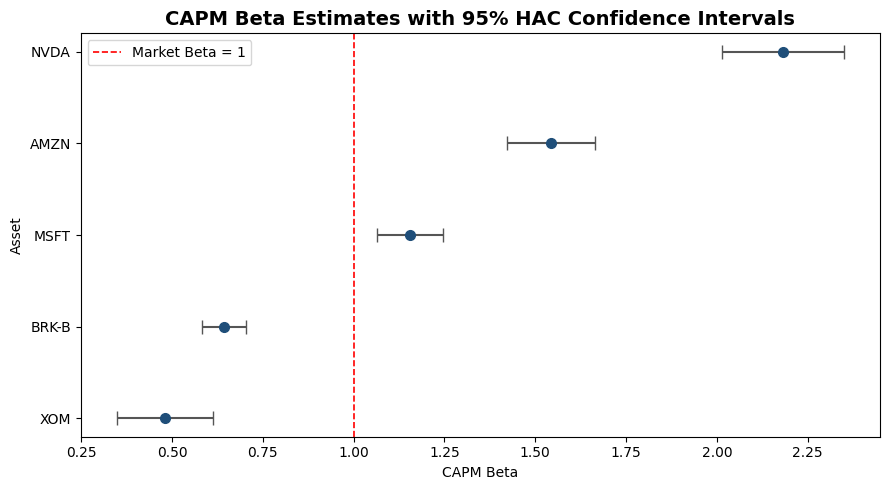

In [76]:
# ============================================================
# 12.18 BETA CONFIDENCE INTERVAL PLOT
# ============================================================

plot_data = beta_ci.sort_values("Beta")

plt.figure(figsize=(9, 5))

y_positions = np.arange(len(plot_data))

plt.errorbar(
    plot_data["Beta"],
    y_positions,
    xerr=[
        plot_data["Beta"] - plot_data["Lower 95%"],
        plot_data["Upper 95%"] - plot_data["Beta"]
    ],
    fmt="o",
    color="#1F4E79",
    ecolor="#555555",
    capsize=5,
    markersize=7
)

plt.axvline(
    1,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label="Market Beta = 1"
)

plt.yticks(
    y_positions,
    plot_data.index
)

plt.xlabel("CAPM Beta")
plt.ylabel("Asset")

plt.title(
    "CAPM Beta Estimates with 95% HAC Confidence Intervals",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()
plt.show()


In [77]:
beta_ci.round(3)


,Beta,Lower 95%,Upper 95%
AMZN,1.544000,1.423000,1.665000
NVDA,2.182000,2.015000,2.349000
MSFT,1.155000,1.066000,1.245000
XOM,0.482000,0.349000,0.614000
BRK-B,0.644000,0.584000,0.705000


In [79]:
# ============================================================
# 13.1 CHECK RETURN DATA
# ============================================================

print(returns.shape)
display(returns[ASSETS].head())


(1002, 6)


Ticker,AMZN,NVDA,MSFT,XOM,BRK-B
Date,,,,,
2022-01-04,-0.016916,-0.027589,-0.017147,0.037614,0.025732
2022-01-05,-0.018893,-0.057562,-0.038388,0.012437,0.004505
2022-01-06,-0.006711,0.020794,-0.007902,0.023521,0.010648
2022-01-07,-0.004288,-0.033040,0.000510,0.008197,0.020944
2022-01-10,-0.006570,0.005615,0.000732,-0.005953,-0.002658


In [80]:
# ============================================================
# 13.2 HISTORICAL VaR
# ============================================================

CONFIDENCE_LEVELS = [0.95, 0.99]

historical_var = pd.DataFrame(index=ASSETS)

for confidence in CONFIDENCE_LEVELS:

    alpha = 1 - confidence

    historical_var[
        f"VaR_{int(confidence * 100)}%"
    ] = -returns[ASSETS].quantile(alpha)

print("Historical VaR:")
display((historical_var * 100).round(2))


Historical VaR:


,VaR_95%,VaR_99%
AMZN,3.430000,5.950000
NVDA,5.200000,7.810000
MSFT,2.680000,4.230000
XOM,2.610000,4.470000
BRK-B,1.680000,2.810000


In [81]:
# ============================================================
# 13.3 PARAMETRIC VaR
# ============================================================

from scipy.stats import norm

parametric_var = pd.DataFrame(index=ASSETS)

mu = returns[ASSETS].mean()
sigma = returns[ASSETS].std()

for confidence in CONFIDENCE_LEVELS:

    alpha = 1 - confidence
    z_alpha = norm.ppf(alpha)

    parametric_var[
        f"VaR_{int(confidence * 100)}%"
    ] = -(mu + z_alpha * sigma)

print("Parametric VaR:")
display((parametric_var * 100).round(2))


Parametric VaR:


,VaR_95%,VaR_99%
AMZN,3.820000,5.420000
NVDA,5.350000,7.660000
MSFT,2.720000,3.870000
XOM,2.630000,3.760000
BRK-B,1.780000,2.540000


In [82]:
# ============================================================
# 13.4 EXPECTED SHORTFALL
# ============================================================

expected_shortfall = pd.DataFrame(index=ASSETS)

for confidence in CONFIDENCE_LEVELS:

    alpha = 1 - confidence

    threshold = returns[ASSETS].quantile(alpha)

    es_values = {}

    for asset in ASSETS:

        tail_losses = returns[asset][
            returns[asset] <= threshold[asset]
        ]

        es_values[asset] = -tail_losses.mean()

    expected_shortfall[
        f"ES_{int(confidence * 100)}%"
    ] = pd.Series(es_values)

print("Expected Shortfall:")
display((expected_shortfall * 100).round(2))


Expected Shortfall:


,ES_95%,ES_99%
AMZN,5.250000,8.260000
NVDA,6.970000,9.570000
MSFT,3.710000,5.160000
XOM,3.770000,5.670000
BRK-B,2.430000,3.700000


In [84]:
# ============================================================
# 13.6 VaR METHOD DIFFERENCES
# ============================================================

var_method_comparison = pd.DataFrame(index=ASSETS)

for confidence in CONFIDENCE_LEVELS:

    level = int(confidence * 100)

    var_method_comparison[
        f"Historical_{level}"
    ] = historical_var[f"VaR_{level}%"]

    var_method_comparison[
        f"Parametric_{level}"
    ] = parametric_var[f"VaR_{level}%"]

    var_method_comparison[
        f"Difference_{level}"
    ] = (
        historical_var[f"VaR_{level}%"]
        - parametric_var[f"VaR_{level}%"]
    )

display(
    (var_method_comparison * 100).round(3)
)


,Historical_95,Parametric_95,Difference_95,Historical_99,Parametric_99,Difference_99
AMZN,3.434000,3.815000,-0.381000,5.947000,5.420000,0.527000
NVDA,5.196000,5.345000,-0.150000,7.805000,7.659000,0.146000
MSFT,2.677000,2.720000,-0.044000,4.232000,3.870000,0.362000
XOM,2.614000,2.635000,-0.021000,4.471000,3.765000,0.706000
BRK-B,1.684000,1.778000,-0.093000,2.814000,2.538000,0.276000


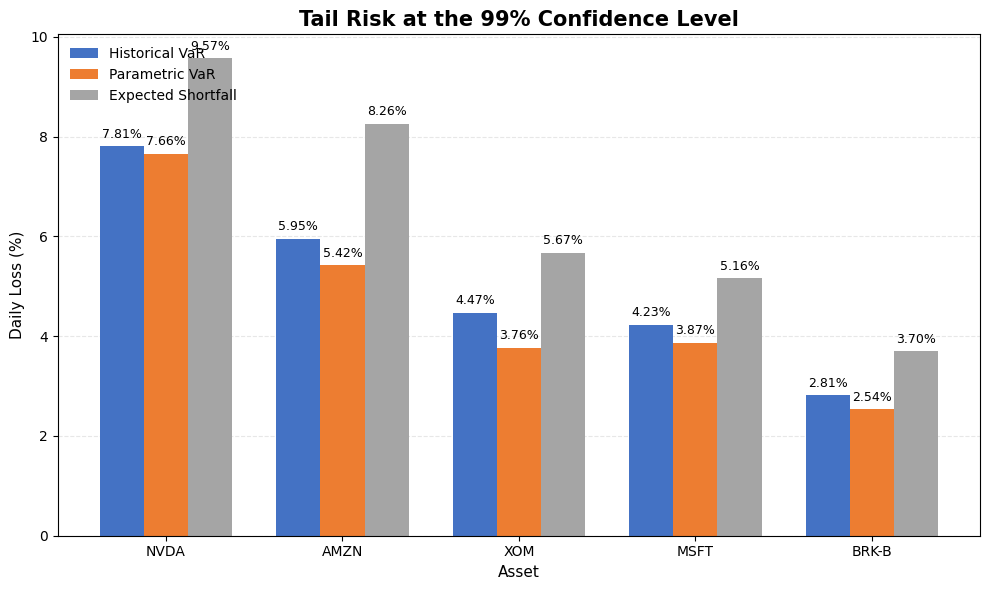

In [83]:
# ============================================================
# 13.7 TAIL RISK AT 99% CONFIDENCE LEVEL
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

tail_risk_99 = pd.DataFrame({
    "Historical VaR": historical_var["VaR_99%"] * 100,
    "Parametric VaR": parametric_var["VaR_99%"] * 100,
    "Expected Shortfall": expected_shortfall["ES_99%"] * 100
})

# Reorder assets by Expected Shortfall
tail_risk_99 = tail_risk_99.sort_values(
    "Expected Shortfall",
    ascending=False
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(tail_risk_99))
width = 0.25

bars1 = ax.bar(
    x - width,
    tail_risk_99["Historical VaR"],
    width,
    label="Historical VaR",
    color="#4472C4"
)

bars2 = ax.bar(
    x,
    tail_risk_99["Parametric VaR"],
    width,
    label="Parametric VaR",
    color="#ED7D31"
)

bars3 = ax.bar(
    x + width,
    tail_risk_99["Expected Shortfall"],
    width,
    label="Expected Shortfall",
    color="#A5A5A5"
)

# ------------------------------------------------------------
# Labels and formatting
# ------------------------------------------------------------

ax.set_title(
    "Tail Risk at the 99% Confidence Level",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Asset",
    fontsize=11
)

ax.set_ylabel(
    "Daily Loss (%)",
    fontsize=11
)

ax.set_xticks(x)
ax.set_xticklabels(tail_risk_99.index)

ax.legend(
    frameon=False,
    loc="upper left"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

ax.set_axisbelow(True)

# ------------------------------------------------------------
# Add values above bars
# ------------------------------------------------------------

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()

        ax.annotate(
            f"{height:.2f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )

# ------------------------------------------------------------
# Final layout
# ------------------------------------------------------------

plt.tight_layout()

plt.show()
